In [1]:
import pandas as pd
import numpy as np
import pingouin as pg
import seaborn as sns
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import PercentFormatter

from utils import radar_factory

#sns.set()
#sns.set_style('darkgrid')
sns.set_theme()
pd.set_option('display.max_colwidth',3000)

In [2]:
def calcula_nivel_maturidade(row, chave='iGovTI'):
    if row[chave] < 0.15:
        return 'Inexpressivo'
    elif row[chave] < 0.4:
        return 'Iniciando'
    elif row[chave] < 0.7:
        return 'Intermediário'
    else:
        return 'Aprimorado'

In [3]:
df_jurisdicionados        = pd.read_excel('../_dados/jurisdicionados.xlsx').set_index('orgao')
df_resultado_setoriais    = pd.read_excel('dados/resultado_igovti.xlsx').set_index('attribute_1')
df_resultado_proderj      = pd.read_excel('dados/resultado_igovti_PRODERJ_2022.xlsx').set_index('attribute_1')
df_resultado_igovti       = pd.concat([df_resultado_proderj, df_resultado_setoriais])
df_resultado_igovti       = df_resultado_igovti.join(df_jurisdicionados)

# Conjunto de órgãos que serão removidos para o cálculo das médias setoriais (pares) e geral
# Esses órgão serão removidos pois apresentam mais de 25% de suas respostas marcadas como 'Não se aplica' 
# que possui nota padrão de 0.5 e assim distorcem as estatísticas
orgaos_outliers = ['CASERJ', 'GVG', 'IASERJ', 'SEIC', 'SEAS', 'SETD']
df_resultado_igovti['r4nk'] = df_resultado_igovti.loc[~df_resultado_igovti.index.isin(orgaos_outliers)]['iGovTI'].rank(ascending=False)

df_resultado_igovti['outliers'] = df_resultado_igovti.index.isin(orgaos_outliers)
df_resultado_igovti['nivel_maturidade'] = df_resultado_igovti.apply(calcula_nivel_maturidade, axis=1)
df_resultado_igovti_ex_outliers = df_resultado_igovti[~df_resultado_igovti['outliers']]

In [4]:
df_resultado_igovti_ex_outliers.sort_values(by='r4nk').head(5)

,q1133,q1133A,q1133B,q1133C,q1133D,q1133E,q1133F,q1131,q1131A,q1131B,...,iGestTI,iGovTI,ProcessosContratacao,Tipo Administração,Tipo Direito,Natureza Jurídica,Fonte,r4nk,outliers,nivel_maturidade
attribute_1,,,,,,,,,,,,,,,,,,,,,
PRODERJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.909023,0.718105,NaN,Indireta,Público,Autarquia,NaN,1.0,False,Aprimorado
AGERIO,0.150000,0.0,0.0,0.0,0.0,0.0,0.0,0.433333,0.0,0.0,...,0.675123,0.716952,0.896850,Indireta,Privado,SEM,NaN,2.0,False,Aprimorado
JUCERJA,0.325000,1.0,0.0,1.0,1.0,0.0,0.0,0.150000,0.0,0.0,...,0.628536,0.673727,0.780132,Indireta,Público,Autarquia,Decreto n.º 11708 de 15 de agosto de 1988,3.0,False,Intermediário
PGE,0.716667,1.0,0.0,1.0,1.0,1.0,0.0,0.050000,0.0,0.0,...,0.688175,0.658621,1.000000,Direta,Público,Órgão Público,NaN,4.0,False,Intermediário
ISP,0.575000,0.0,0.0,1.0,1.0,1.0,0.0,0.716667,1.0,1.0,...,0.654021,0.478851,0.727754,Indireta,Público,Autarquia,"Lei nº 3.329, de 28 de Dezembro 1999",5.0,False,Intermediário


In [5]:
df_resultado_igovti_ex_outliers.sort_values(by='r4nk').tail(5)

,q1133,q1133A,q1133B,q1133C,q1133D,q1133E,q1133F,q1131,q1131A,q1131B,...,iGestTI,iGovTI,ProcessosContratacao,Tipo Administração,Tipo Direito,Natureza Jurídica,Fonte,r4nk,outliers,nivel_maturidade
attribute_1,,,,,,,,,,,,,,,,,,,,,
FAETEC,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.05,0.0,0.0,...,0.047888,0.042401,0.050000,Indireta,Público,Fundação,Decreto 42.327/2010,64.0,False,Inexpressivo
AGETRANSP,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.05,0.0,0.0,...,0.045088,0.035598,0.765280,Indireta,Público,Autarquia,NaN,65.0,False,Inexpressivo
IRM,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.019754,0.009877,0.022767,Indireta,Público,Autarquia,DECRETO Nº 46.893 DE 23 DE DEZEMBRO DE 2019,66.0,False,Inexpressivo
DER/RJ,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.015415,0.007707,0.138754,Indireta,Privado,Fundação,NaN,67.0,False,Inexpressivo
PESAGRO,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.010437,0.005218,0.000000,Indireta,Privado,Empresa Pública,Estatuto,68.0,False,Inexpressivo


# Análises relativas ao iGovTI

## iGovTI

### Níveis de Maturidade

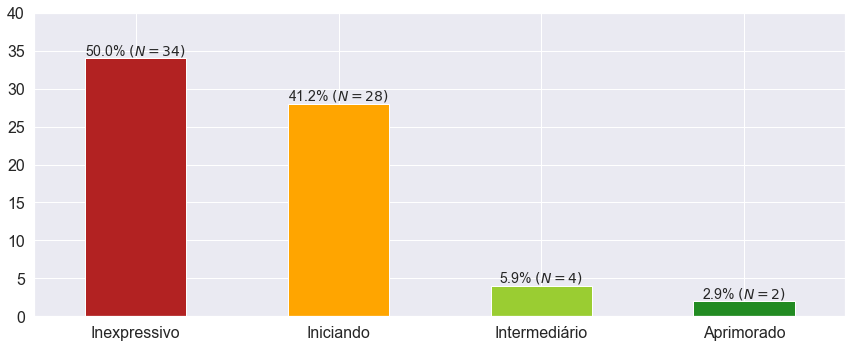

In [281]:
dados = df_resultado_igovti_ex_outliers['nivel_maturidade'].value_counts()
ax = dados\
    .plot.bar(figsize=(12, 5), rot=0,
              color=['firebrick', 'orange', 'yellowgreen', 'forestgreen'], fontsize=16)

labels = [f'{100*d/dados.sum():.1f}% $(N={d})$' for d in dados.values]

for container in ax.containers:
    ax.bar_label(container, labels, fontsize=14)
ax.set_ylim([0, 40])
plt.tight_layout()

### Notas iGovTI

Text(0.5, 1.0, 'Organizações do SETIC')

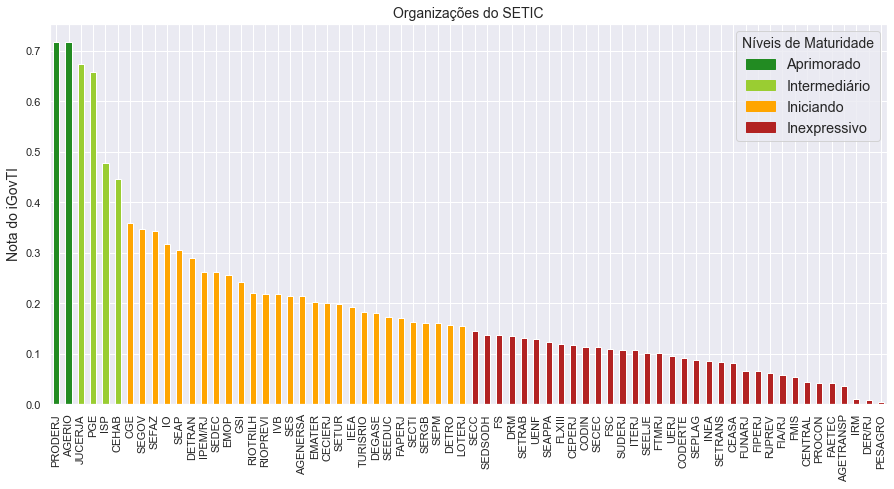

In [296]:
dados = df_resultado_igovti_ex_outliers.sort_values(by='iGovTI', ascending=False)

def get_color(d):
    if d == 'Inexpressivo': return 'firebrick'
    elif d == 'Iniciando': return 'orange'
    elif d == 'Intermediário': return 'yellowgreen'
    else: return 'forestgreen'

cores = [ get_color(d) for d in dados['nivel_maturidade']]

ax = dados['iGovTI']\
    .plot.bar(figsize=(15, 7),color=cores)


legendas = [
    ('Aprimorado', 'forestgreen'),
    ('Intermediário', 'yellowgreen'),
    ('Iniciando', 'orange'),    
    ('Inexpressivo', 'firebrick')
]

m_legs = [ mpatches.Patch(color=l[1], label=l[0]) for l in legendas]
ax.legend(handles=m_legs,  fontsize='large', title='Níveis de Maturidade', title_fontsize=14)

ax.set_xlabel('')
ax.set_ylabel('Nota do iGovTI', fontsize=14)
ax.set_title('Organizações do SETIC', fontsize=14)

### Distribuição de notas do iGovTI

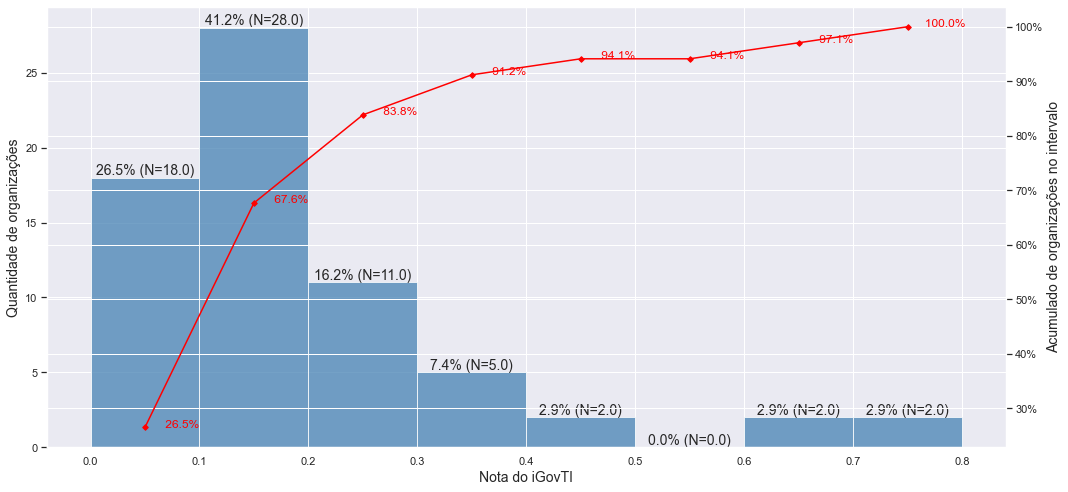

In [289]:
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
dados = df_resultado_igovti_ex_outliers.sort_values(by='iGovTI', ascending=False)

n, bins, patches = ax.hist(dados['iGovTI'], bins=[0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], facecolor='steelblue', alpha=0.75)

ax.set_xlabel('Nota do iGovTI', fontsize=14)
ax.set_ylabel('Quantidade de organizações', fontsize=14)
#ax.set_title('Histograma e Pareto')
ax.set_xticks(bins, fontsize=14)

labels = [f'{100*d/n.sum():.1f}% (N={d})' for d in n]
for container in ax.containers:
    ax.bar_label(container, labels, fontsize=14)

# Cria o Pareto
fq = 100*np.cumsum(n)/n.sum()
x = [(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)]

ax2 = ax.twinx()
ax2.plot(x, fq, color='red', marker='D', ms=4)
ax2.set_ylabel('Acumulado de organizações no intervalo', fontsize=14)

for i, txt in enumerate(fq):
    plt.annotate("{:10.1f}%".format(txt), (x[i], fq[i]), color='red')

ax2.yaxis.set_major_formatter(PercentFormatter())

plt.tight_layout()

### Top 20 melhores notas do iGovTI

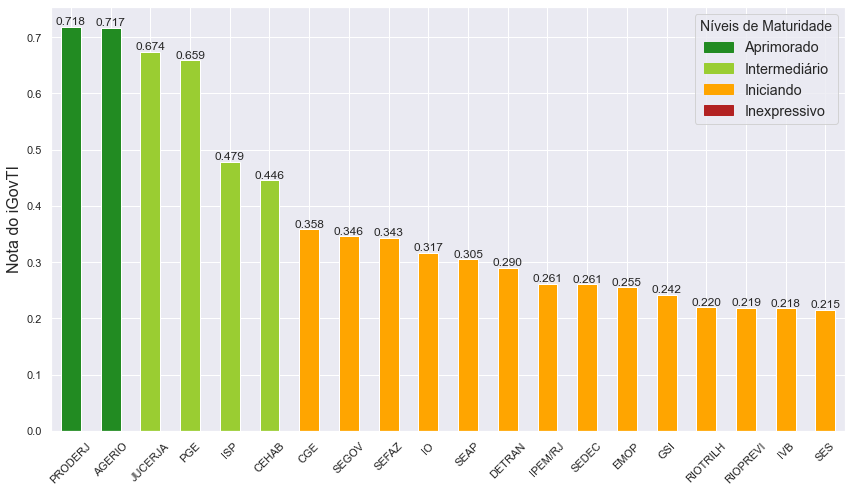

In [294]:
dados = df_resultado_igovti_ex_outliers.sort_values(by='iGovTI', ascending=False).head(20)

def get_color(d):
    if d == 'Inexpressivo': return 'firebrick'
    elif d == 'Iniciando': return 'orange'
    elif d == 'Intermediário': return 'yellowgreen'
    else: return 'forestgreen'

cores = [ get_color(d) for d in dados['nivel_maturidade']]

ax = dados['iGovTI']\
    .plot.bar(figsize=(12, 7), rot=45, color=cores)

legendas = [
    ('Aprimorado', 'forestgreen'),
    ('Intermediário', 'yellowgreen'),
    ('Iniciando', 'orange'),    
    ('Inexpressivo', 'firebrick')
]

m_legs = [ mpatches.Patch(color=l[1], label=l[0]) for l in legendas]
ax.legend(handles=m_legs,  fontsize='large', title='Níveis de Maturidade', title_fontsize=14)

ax.set_xlabel('')
ax.set_ylabel('Nota do iGovTI', fontsize=16)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')
    
plt.tight_layout()

### Análise setorial (Adm Direta / Adm Indireta)

In [11]:
df_resultado_igovti_ex_outliers = df_resultado_igovti[~df_resultado_igovti['r4nk'].isna()]
df_medias = pd.concat([
    df_resultado_igovti.filter(regex='^([^0-9]*)$').mean(), 
    df_resultado_igovti_ex_outliers.filter(regex='^([^0-9]*)$').mean(),
    df_resultado_igovti_ex_outliers.groupby(['Tipo Administração']).mean().filter(regex='^([^0-9]*)$').T,
    df_resultado_igovti_ex_outliers.groupby(['Natureza Jurídica']).mean().filter(regex='^([^0-9]*)$').T
], axis=1)

df_medias.columns = ['Média Geral', 'Média Ajustada (ex-outliers)', 'Administração Direta', 'Administração Indireta', 'Autarquia', 'Empresa Pública', 'Fundação', 'Sociedade de Economia Mista', 'Órgão Público']

C:\Users\augustocba\AppData\Local\Temp\2\ipykernel_17876\726501365.py:3: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_resultado_igovti.filter(regex='^([^0-9]*)$').mean(),
C:\Users\augustocba\AppData\Local\Temp\2\ipykernel_17876\726501365.py:4: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_resultado_igovti_ex_outliers.filter(regex='^([^0-9]*)$').mean(),
C:\Users\augustocba\AppData\Local\Temp\2\ipykernel_17876\726501365.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future 

In [25]:
df_medias

,Média Geral,Média Ajustada (ex-outliers),Administração Direta,Administração Indireta,Autarquia,Empresa Pública,Fundação,Sociedade de Economia Mista,Órgão Público
ResultadoTI,0.217305,0.194283,0.232635,0.175941,0.190401,0.223702,0.126308,0.214630,0.232635
ModeloTI,0.177553,0.171650,0.216414,0.150242,0.171895,0.198889,0.074653,0.225000,0.216414
MonitorAvaliaTI,0.081775,0.079021,0.068963,0.083832,0.098531,0.047391,0.019496,0.204044,0.068963
PessoasTI,0.217517,0.222243,0.173439,0.245585,0.360772,0.117511,0.108154,0.355719,0.173439
PlanejamentoTI,0.308607,0.314461,0.395644,0.275634,0.364706,0.232500,0.160268,0.344048,0.395644
iGestServicosTI,0.152524,0.153182,0.151459,0.154006,0.197374,0.292171,0.052524,0.178460,0.151459
iGestNiveisServicoTI,0.095054,0.088123,0.095833,0.084435,0.077491,0.070000,0.044271,0.188542,0.095833
iGestRiscosTI,0.125084,0.119631,0.138893,0.110419,0.125009,0.136577,0.039646,0.204614,0.138893
EstruturaSegInfo,0.130505,0.129510,0.099837,0.143701,0.214604,0.160456,0.063852,0.142258,0.099837
ProcessoSegInfo,0.177136,0.174381,0.218842,0.153117,0.213531,0.174934,0.061071,0.195194,0.218842


### Médias

In [12]:
df_medias.loc[['iGovTI', 'iGestTI', 'GovernancaTI'], ['Média Ajustada (ex-outliers)', 'Administração Direta', 'Autarquia', 'Empresa Pública', 'Fundação', 'Sociedade de Economia Mista']].applymap('{:.4f}'.format)

,Média Ajustada (ex-outliers),Administração Direta,Autarquia,Empresa Pública,Fundação,Sociedade de Economia Mista
iGovTI,0.1912,0.2131,0.2284,0.1650,0.0957,0.2589
iGestTI,0.2355,0.2555,0.3044,0.1754,0.1196,0.3032
GovernancaTI,0.1468,0.1707,0.1524,0.1545,0.0718,0.2145


### Visão geral das médias

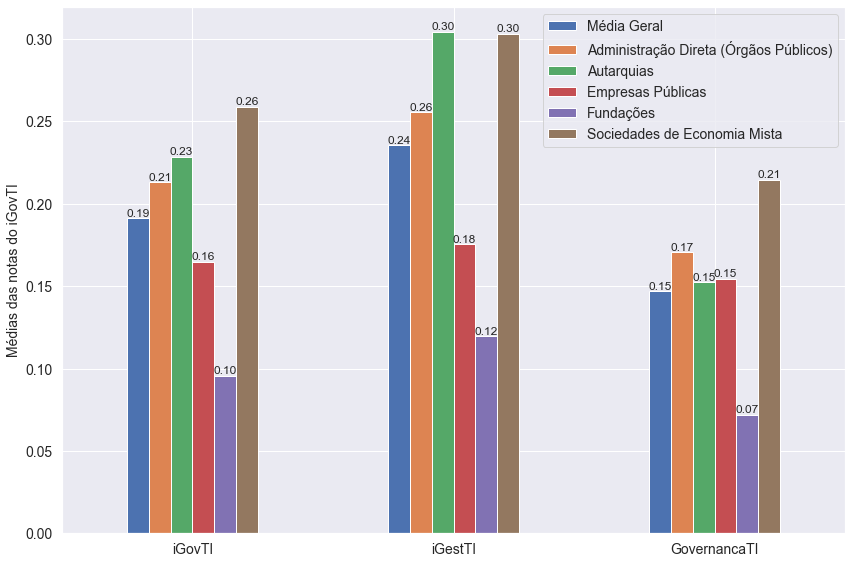

In [302]:
ax = df_medias.loc[['iGovTI', 'iGestTI', 'GovernancaTI'], ['Média Ajustada (ex-outliers)', 'Administração Direta', 'Autarquia', 'Empresa Pública', 'Fundação', 'Sociedade de Economia Mista']] \
    .plot.bar(figsize=(12,8), rot=0, fontsize=14)

ax.legend([
    'Média Geral', 'Administração Direta (Órgãos Públicos)', 'Autarquias', 'Empresas Públicas', 'Fundações', 'Sociedades de Economia Mista'
], fontsize=14)

ax.set_ylabel('Médias das notas do iGovTI', fontsize=14)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

In [41]:
df_resultado_igovti_ex_outliers.filter(regex='^([^0-9]*)$').sort_values(by='iGovTI', ascending=False)[
    ['iGovTI', 'iGestTI', 'GovernancaTI']
].describe()

,iGovTI,iGestTI,GovernancaTI
count,68.000000,68.000000,68.000000
mean,0.191171,0.235497,0.146845
std,0.160069,0.194457,0.153491
min,0.005218,0.010437,0.000000
25%,0.094545,0.092200,0.053227
50%,0.150106,0.190632,0.110741
75%,0.219208,0.295533,0.162755
max,0.718105,0.909023,0.758782


Text(0.5, 0, 'Notas dos agregados')

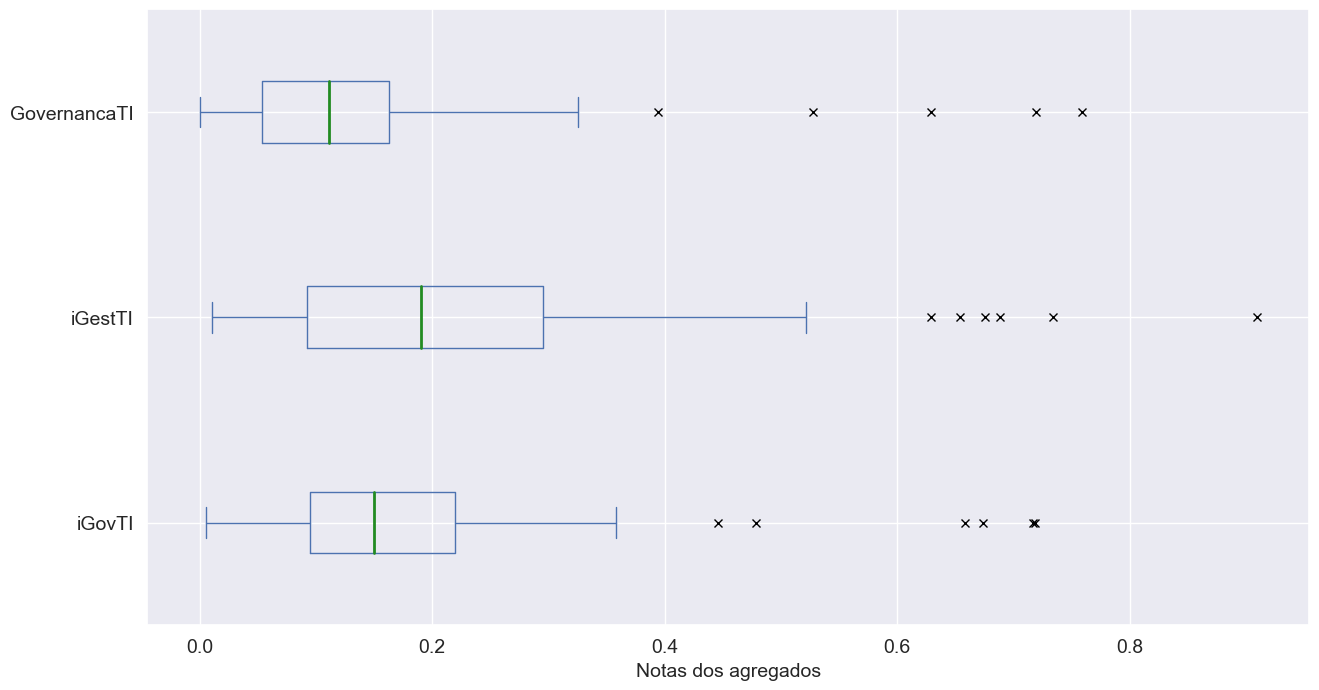

In [16]:
ax = df_resultado_igovti_ex_outliers.filter(regex='^([^0-9]*)$').sort_values(by='iGovTI', ascending=False)[
    ['iGovTI', 'iGestTI', 'GovernancaTI']
].plot.box(vert=False, figsize=(15, 8), fontsize=14, medianprops = dict(color = "forestgreen", linewidth = 2), flierprops = dict(marker = "x"))

ax.set_xlabel('Notas dos agregados', fontsize=14)

## Componentes do GovernancaTI

### Níveis de capacidade

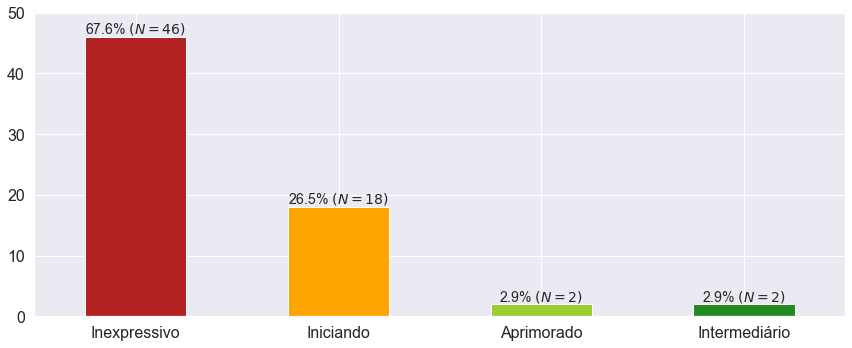

In [306]:
def get_nivel_capacidade(d):
    if d < 0.15: return 'Inexpressivo'
    elif d < 0.4: return 'Iniciando'
    elif d < 0.7: return 'Intermediário'
    else: return 'Aprimorado'

dados = df_resultado_igovti_ex_outliers.sort_values(by='GovernancaTI', ascending=False)
dados['nivel_capacidade'] = dados['GovernancaTI'].apply(get_nivel_capacidade)
dados = dados['nivel_capacidade'].value_counts()

ax = dados \
    .plot.bar(figsize=(12, 5), rot=0,
              color=['firebrick', 'orange', 'yellowgreen', 'forestgreen'], fontsize=16)

labels = [f'{100*d/dados.sum():.1f}% $(N={d})$' for d in dados.values]

ax.set_ylim([0, 50])
for container in ax.containers:
    ax.bar_label(container, labels, fontsize=14)
    
plt.tight_layout()

### Médias

In [226]:
df_medias.loc[['GovernancaTI', 'ModeloTI', 'MonitorAvaliaTI', 'ResultadoTI'][::-1], ['Média Ajustada (ex-outliers)', 'Administração Direta', 'Autarquia', 'Empresa Pública', 'Fundação', 'Sociedade de Economia Mista']].applymap('{:.4f}'.format)

,Média Ajustada (ex-outliers),Administração Direta,Autarquia,Empresa Pública,Fundação,Sociedade de Economia Mista
ResultadoTI,0.1943,0.2326,0.1904,0.2237,0.1263,0.2146
MonitorAvaliaTI,0.0790,0.0690,0.0985,0.0474,0.0195,0.2040
ModeloTI,0.1717,0.2164,0.1719,0.1989,0.0747,0.2250
GovernancaTI,0.1468,0.1707,0.1524,0.1545,0.0718,0.2145


### Visão geral das médias

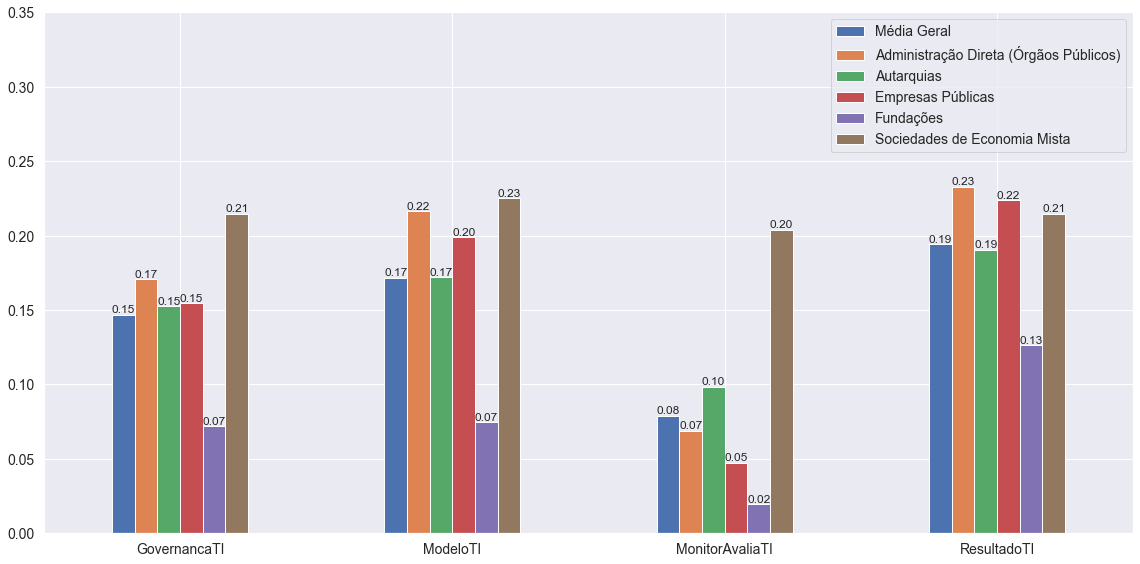

In [312]:
ax = df_medias.loc[['GovernancaTI', 'ModeloTI', 'MonitorAvaliaTI', 'ResultadoTI'], ['Média Ajustada (ex-outliers)', 'Administração Direta', 'Autarquia', 'Empresa Pública', 'Fundação', 'Sociedade de Economia Mista']]\
    .plot.bar(figsize=(16, 8), rot=0, fontsize=14)

ax.legend([
    'Média Geral', 'Administração Direta (Órgãos Públicos)', 'Autarquias', 'Empresas Públicas', 'Fundações', 'Sociedades de Economia Mista'
], fontsize=14)

ax.set_ylim([0, 0.35])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

### Radar das médias

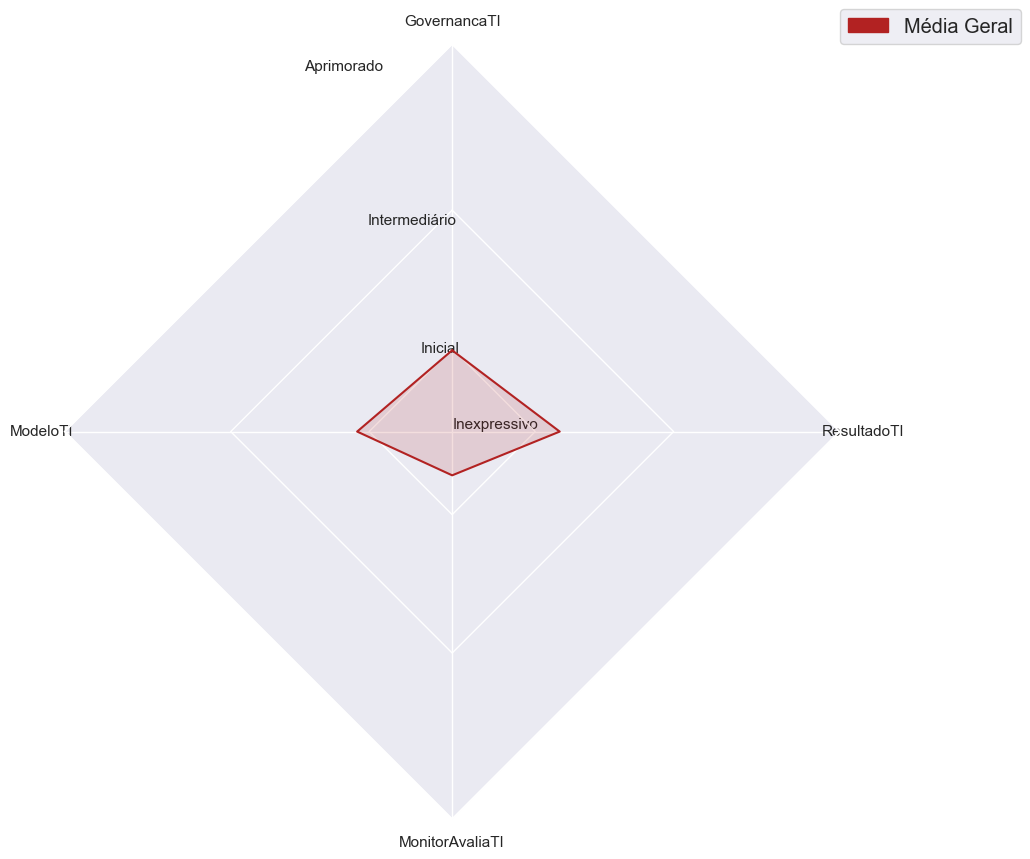

In [30]:
colunas = ['GovernancaTI', 'ModeloTI', 'MonitorAvaliaTI', 'ResultadoTI']

dic = [
    ('Média Geral', 'firebrick'),
    #('Administração Direta (Órgãos Públicos)', 'orange'),
    #('Autarquias', 'steelblue'),
    #('Empresas Públicas', 'black'),
    #('Fundações', 'steelblue'),
    #('Sociedades de Economia Mista', 'forestgreen'),
]

m_legs = []
for l in dic:
    m_legs.append(mpatches.Patch(color=l[1], label=l[0]))

N = len(colunas)
theta = radar_factory(N, frame='polygon')

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='radar'))
fig.subplots_adjust(wspace=0.25, hspace=0.20, top=0.85, bottom=0.05)

for d, color in zip([
    df_medias['Média Ajustada (ex-outliers)'].T[colunas], 
    #df_medias['Administração Direta'].T[colunas], 
    #df_medias['Autarquia'].T[colunas], 
    #df_medias['Empresa Pública'].T[colunas], 
    #df_medias['Fundação'].T[colunas], 
    #df_medias['Sociedade de Economia Mista'].T[colunas], 
], dic):
    ax.plot(theta, d, color=color[1], )
    ax.fill(theta, d, facecolor=color[1], alpha=0.15)

    ax.set_varlabels(colunas)
    ax.set_rgrids([0, 0.15, 0.4, 0.7], ['Inexpressivo', 'Inicial', 'Intermediário', 'Aprimorado'])

ax.legend(handles=m_legs, loc=(1, 1), labelspacing=0.5, fontsize='large')

### Estatísticas

In [20]:
df_resultado_igovti_ex_outliers[
    ['GovernancaTI', 'ModeloTI', 'MonitorAvaliaTI', 'ResultadoTI']
].describe()

,GovernancaTI,ModeloTI,MonitorAvaliaTI,ResultadoTI
count,68.000000,68.000000,68.000000,68.000000
mean,0.146845,0.171650,0.079021,0.194283
std,0.153491,0.222314,0.188270,0.146215
min,0.000000,0.000000,0.000000,0.000000
25%,0.053227,0.050000,0.000000,0.095596
50%,0.110741,0.150000,0.035993,0.154956
75%,0.162755,0.150000,0.056989,0.269058
max,0.758782,1.000000,1.000000,0.541832


### Distribuição das notas

Text(0.5, 0, 'Notas dos agregados')

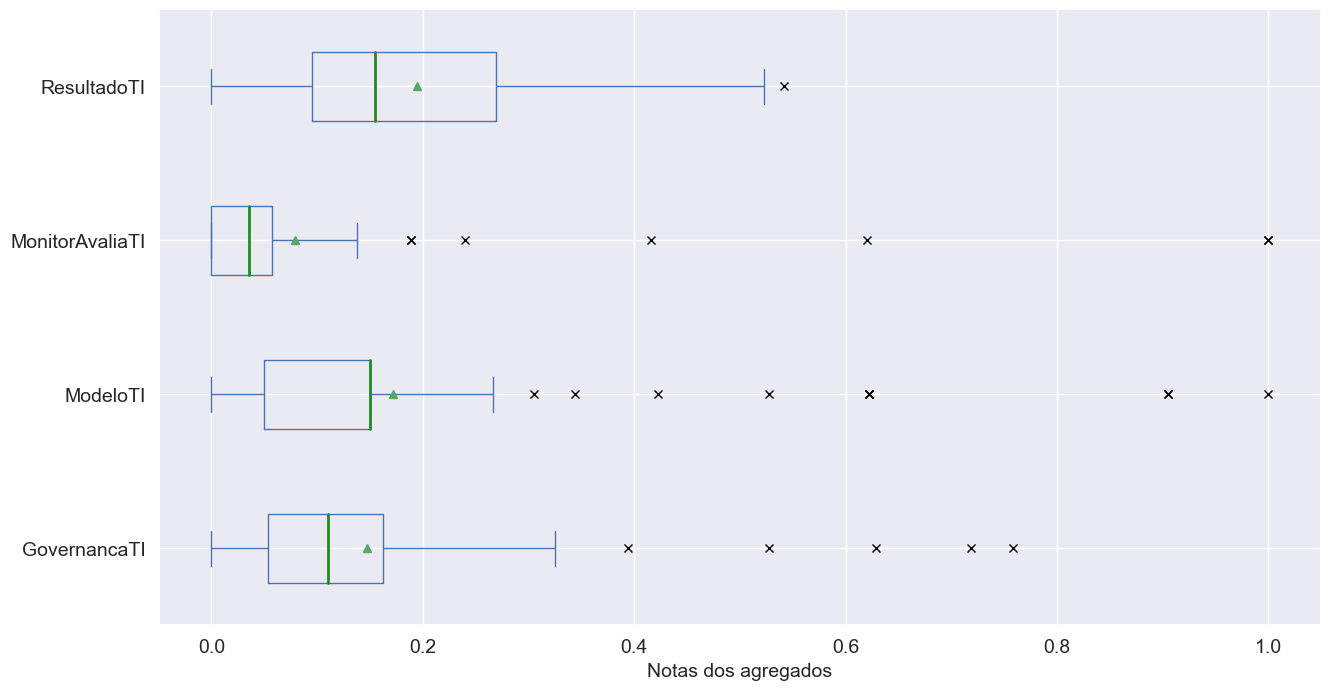

In [21]:
ax = df_resultado_igovti_ex_outliers.filter(regex='^([^0-9]*)$').sort_values(by='GovernancaTI', ascending=False)[
    ['GovernancaTI', 'ModeloTI', 'MonitorAvaliaTI', 'ResultadoTI']
].plot.box(vert=False, figsize=(15, 8), fontsize=14, showmeans=True, medianprops = dict(color = "forestgreen", linewidth = 2), flierprops = dict(marker = "x"))

ax.set_xlabel('Notas dos agregados', fontsize=14)

Text(0.5, 0, 'Notas dos agregados')

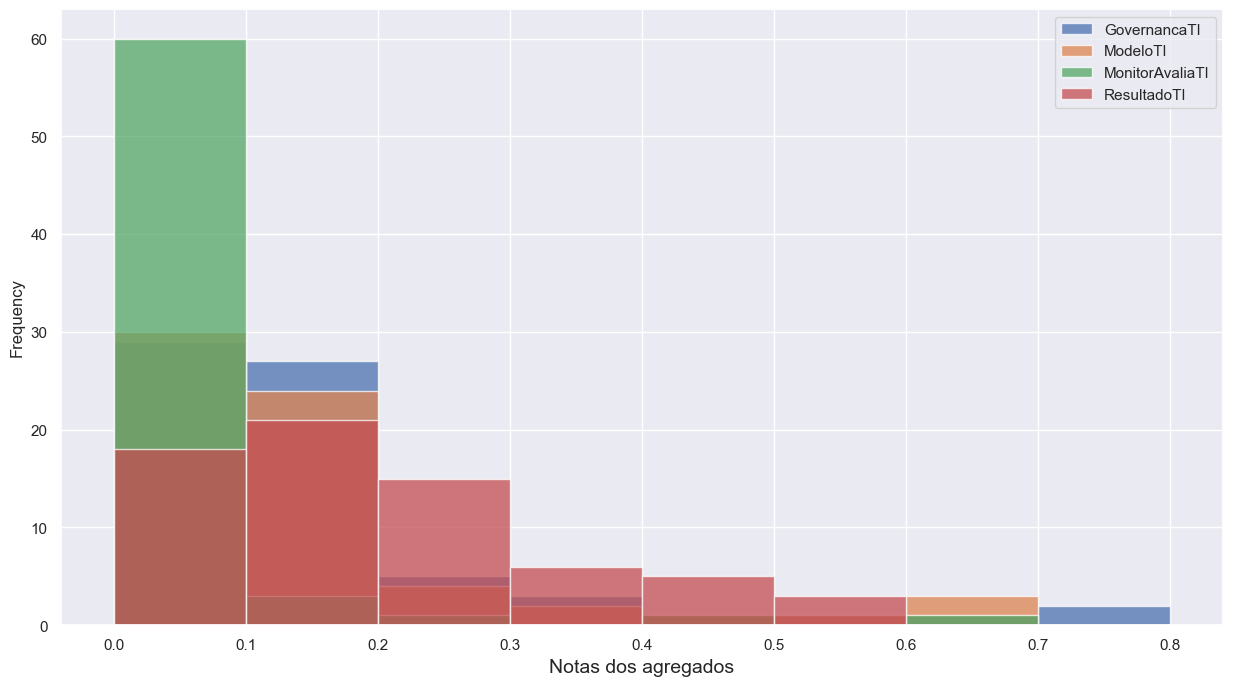

In [22]:
ax = df_resultado_igovti_ex_outliers.filter(regex='^([^0-9]*)$').sort_values(by='GovernancaTI', ascending=False)[
    ['GovernancaTI', 'ModeloTI', 'MonitorAvaliaTI', 'ResultadoTI']
].plot.hist(bins=[0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], alpha=0.75, figsize=(15, 8))

ax.set_xlabel('Notas dos agregados', fontsize=14)

### Top 20 melhores notas do GovernancaTI

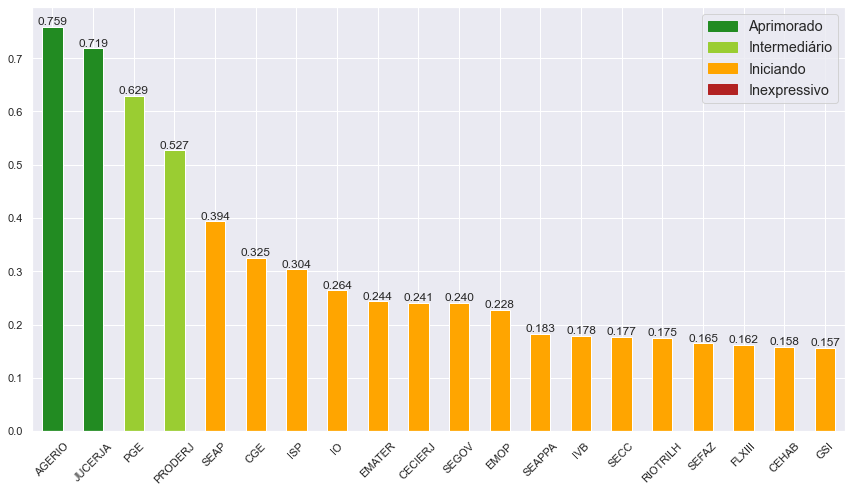

In [260]:
dados = df_resultado_igovti_ex_outliers.sort_values(by='GovernancaTI', ascending=False).head(20)

def get_color(d):
    if d < 0.15: return 'firebrick'
    elif d < 0.4: return 'orange'
    elif d < 0.7: return 'yellowgreen'
    else: return 'forestgreen'

cores = [ get_color(d) for d in dados['GovernancaTI']]

ax = dados['GovernancaTI']\
    .plot.bar(figsize=(12, 7), rot=45, color=cores)

ax.set_xlabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

legendas = [
    ('Aprimorado', 'forestgreen'),
    ('Intermediário', 'yellowgreen'),
    ('Iniciando', 'orange'),    
    ('Inexpressivo', 'firebrick')
]

m_legs = [ mpatches.Patch(color=l[1], label=l[0]) for l in legendas]
ax.legend(handles=m_legs,  fontsize='large')

plt.tight_layout()

## Componentes do iGestTI

### Níveis de capacidade

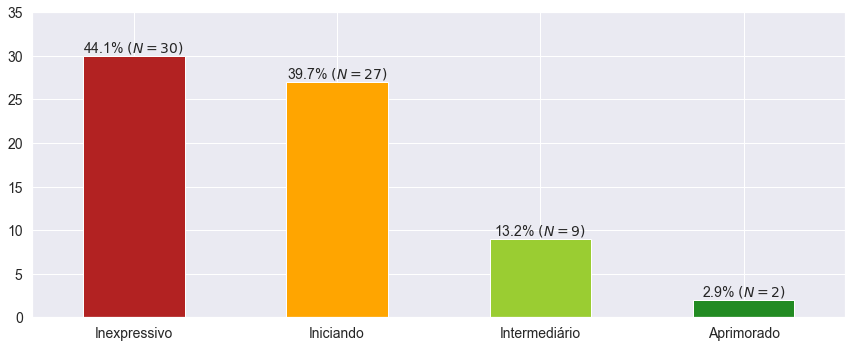

In [314]:
def get_nivel_capacidade(d):
    if d < 0.15: return 'Inexpressivo'
    elif d < 0.4: return 'Iniciando'
    elif d < 0.7: return 'Intermediário'
    else: return 'Aprimorado'

dados = df_resultado_igovti_ex_outliers.sort_values(by='iGestTI', ascending=False)
dados['nivel_capacidade'] = dados['iGestTI'].apply(get_nivel_capacidade)
dados = dados['nivel_capacidade'].value_counts()

ax = dados \
    .plot.bar(figsize=(12, 5), rot=0,
              color=['firebrick', 'orange', 'yellowgreen', 'forestgreen'], fontsize=14)

labels = [f'{100*d/dados.sum():.1f}% $(N={d})$' for d in dados.values]

ax.set_ylim([0, 35])
for container in ax.containers:
    ax.bar_label(container, labels, fontsize=14)
    
plt.tight_layout()

### Médias

In [324]:
cols = ['iGestTI', 'PlanejamentoTI', 'PessoasTI', 'iGestServicosTI', 'iGestSegInfo', 'iGestRiscosTI', 'iGestContratosTI', 'ProcessoSoftware', 'iGestProjetosTI']
df_medias.loc[cols[::-1], ['Média Ajustada (ex-outliers)', 'Administração Direta', 'Autarquia', 'Empresa Pública', 'Fundação', 'Sociedade de Economia Mista']].sort_values(by='Média Ajustada (ex-outliers)', ascending=False)

,Média Ajustada (ex-outliers),Administração Direta,Autarquia,Empresa Pública,Fundação,Sociedade de Economia Mista
iGestContratosTI,0.460088,0.507021,0.526711,0.245074,0.429532,0.384946
PlanejamentoTI,0.314461,0.395644,0.364706,0.232500,0.160268,0.344048
iGestTI,0.235497,0.255514,0.304444,0.175434,0.119628,0.303211
PessoasTI,0.222243,0.173439,0.360772,0.117511,0.108154,0.355719
ProcessoSoftware,0.204718,0.258902,0.207108,0.197500,0.110677,0.243229
iGestProjetosTI,0.164706,0.204545,0.220588,0.138000,0.023125,0.236250
iGestServicosTI,0.153182,0.151459,0.197374,0.292171,0.052524,0.178460
iGestSegInfo,0.125262,0.123240,0.165843,0.125655,0.054230,0.186408
iGestRiscosTI,0.119631,0.138893,0.125009,0.136577,0.039646,0.204614


In [330]:
df_medias.loc[['iGestTI', 'PlanejamentoTI', 'PessoasTI', 'iGestServicosTI', 'iGestSegInfo', 'iGestRiscosTI', 'iGestContratosTI'][::-1], ['Média Ajustada (ex-outliers)', 'Administração Direta', 'Autarquia', 'Empresa Pública', 'Fundação', 'Sociedade de Economia Mista']].applymap('{:.4f}'.format)

,Média Ajustada (ex-outliers),Administração Direta,Autarquia,Empresa Pública,Fundação,Sociedade de Economia Mista
iGestContratosTI,0.4601,0.5070,0.5267,0.2451,0.4295,0.3849
iGestRiscosTI,0.1196,0.1389,0.1250,0.1366,0.0396,0.2046
iGestSegInfo,0.1253,0.1232,0.1658,0.1257,0.0542,0.1864
iGestServicosTI,0.1532,0.1515,0.1974,0.2922,0.0525,0.1785
PessoasTI,0.2222,0.1734,0.3608,0.1175,0.1082,0.3557
PlanejamentoTI,0.3145,0.3956,0.3647,0.2325,0.1603,0.3440
iGestTI,0.2355,0.2555,0.3044,0.1754,0.1196,0.3032


### Visão geral das médias

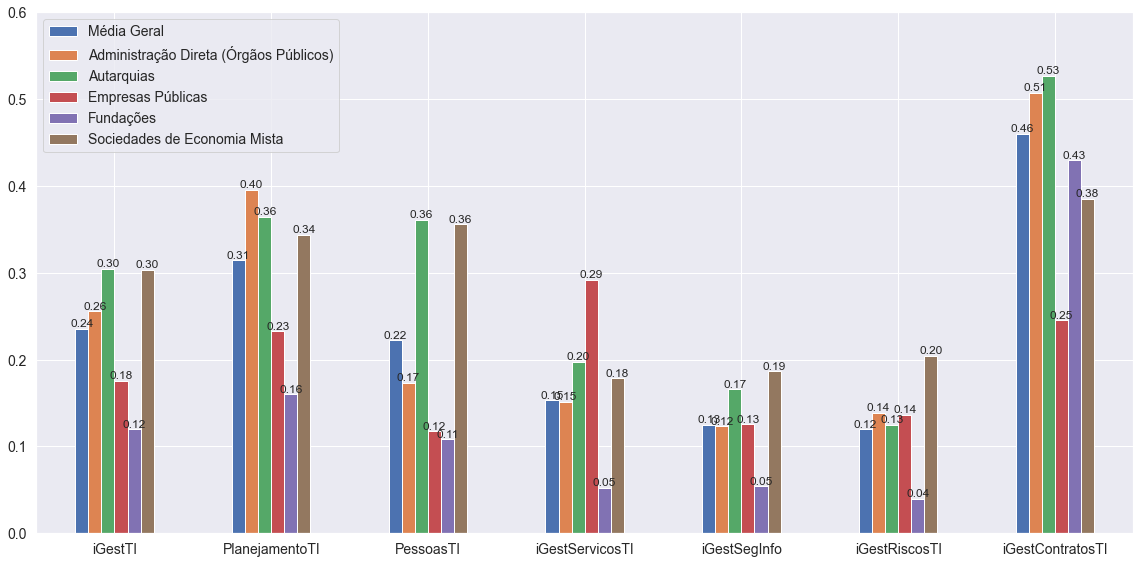

In [327]:
ax = df_medias.loc[['iGestTI', 'PlanejamentoTI', 'PessoasTI', 'iGestServicosTI', 'iGestSegInfo', 'iGestRiscosTI', 'iGestContratosTI'], ['Média Ajustada (ex-outliers)', 'Administração Direta', 'Autarquia', 'Empresa Pública', 'Fundação', 'Sociedade de Economia Mista']]\
    .plot.bar(figsize=(16, 8), rot=0, fontsize=14)

ax.legend([
    'Média Geral', 'Administração Direta (Órgãos Públicos)', 'Autarquias', 'Empresas Públicas', 'Fundações', 'Sociedades de Economia Mista'
], fontsize=14)

ax.set_ylim([0, 0.6])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

### Radar das médias

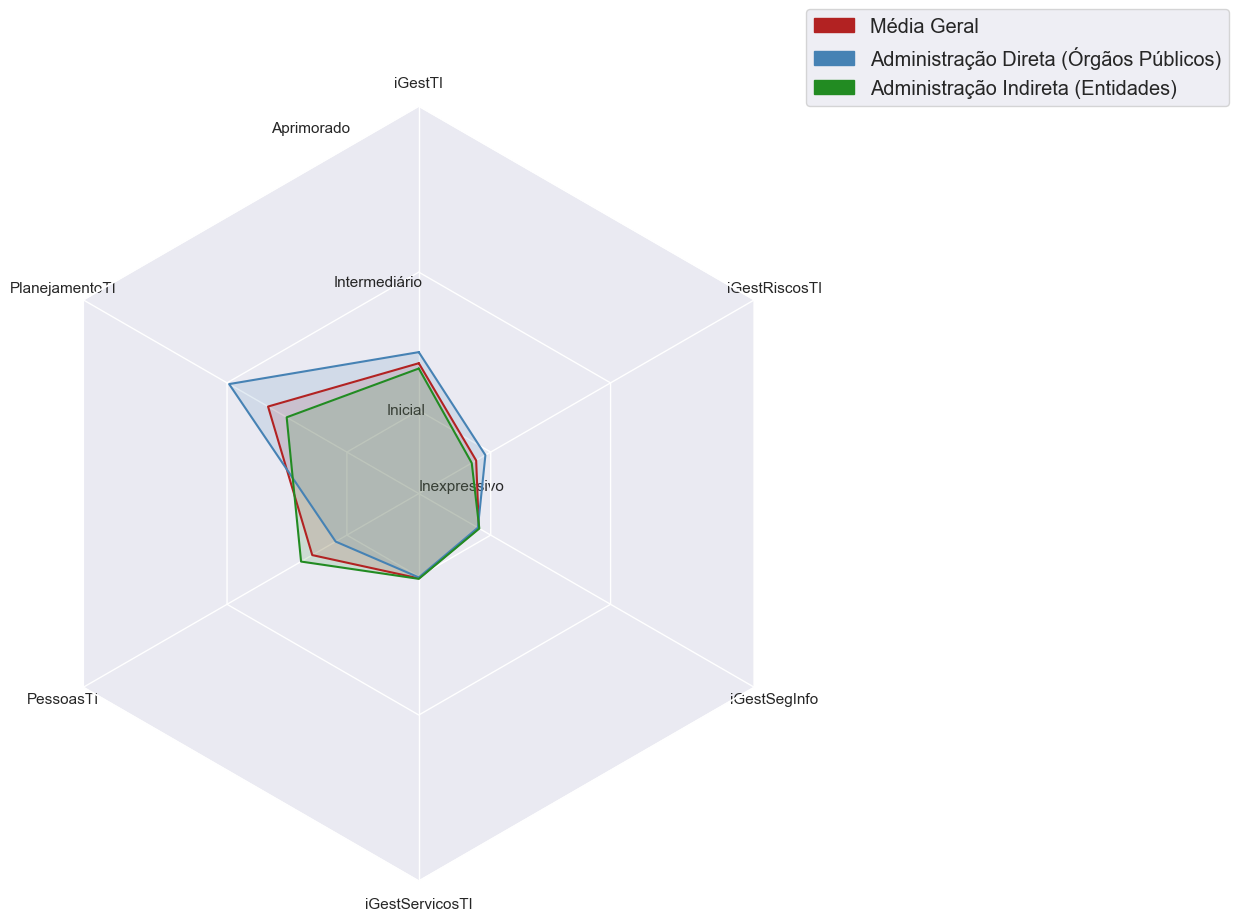

In [33]:
colunas = ['iGestTI', 'PlanejamentoTI', 'PessoasTI', 'iGestServicosTI', 'iGestSegInfo', 'iGestRiscosTI']

dic = [
    ('Média Geral', 'firebrick'),
    ('Administração Direta (Órgãos Públicos)', 'steelblue'),
    ('Administração Indireta (Entidades)', 'forestgreen'),

    #('Autarquias', 'steelblue'),
    #('Empresas Públicas', 'black'),
    #('Fundações', 'steelblue'),
    #('Sociedades de Economia Mista', 'forestgreen'),
]

m_legs = []
for l in dic:
    m_legs.append(mpatches.Patch(color=l[1], label=l[0]))

N = len(colunas)
theta = radar_factory(N, frame='polygon')

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='radar'))
fig.subplots_adjust(wspace=0.25, hspace=0.20, top=0.85, bottom=0.05)

for d, color in zip([
    df_medias['Média Ajustada (ex-outliers)'].T[colunas], 
    df_medias['Administração Direta'].T[colunas],
    df_medias['Administração Indireta'].T[colunas], 
    #df_medias['Administração Direta'].T[colunas], 
    #df_medias['Autarquia'].T[colunas], 
    #df_medias['Empresa Pública'].T[colunas], 
    #df_medias['Fundação'].T[colunas], 
    #df_medias['Sociedade de Economia Mista'].T[colunas], 
], dic):
    ax.plot(theta, d, color=color[1], )
    ax.fill(theta, d, facecolor=color[1], alpha=0.15)

    ax.set_varlabels(colunas)
    ax.set_rgrids([0, 0.15, 0.4, 0.7], ['Inexpressivo', 'Inicial', 'Intermediário', 'Aprimorado'])

ax.legend(handles=m_legs, loc=(1, 1), labelspacing=0.5, fontsize='large')

### Estatísticas

In [328]:
df_resultado_igovti_ex_outliers[
    ['iGestTI', 'PlanejamentoTI', 'PessoasTI', 'iGestServicosTI', 'iGestSegInfo', 'iGestRiscosTI', 'iGestContratosTI']
].describe()

,iGestTI,PlanejamentoTI,PessoasTI,iGestServicosTI,iGestSegInfo,iGestRiscosTI,iGestContratosTI
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,0.235497,0.314461,0.222243,0.153182,0.125262,0.119631,0.460088
std,0.194457,0.313399,0.234771,0.173036,0.156678,0.143115,0.338264
min,0.010437,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.092200,0.075000,0.038457,0.050000,0.039044,0.024809,0.046303
50%,0.190632,0.150000,0.131205,0.087592,0.081917,0.066285,0.394401
75%,0.295533,0.521875,0.329878,0.178686,0.145137,0.156236,0.770139
max,0.909023,1.000000,1.000000,0.865673,0.873995,0.691540,1.000000


Text(0.5, 0, 'Notas dos agregados')

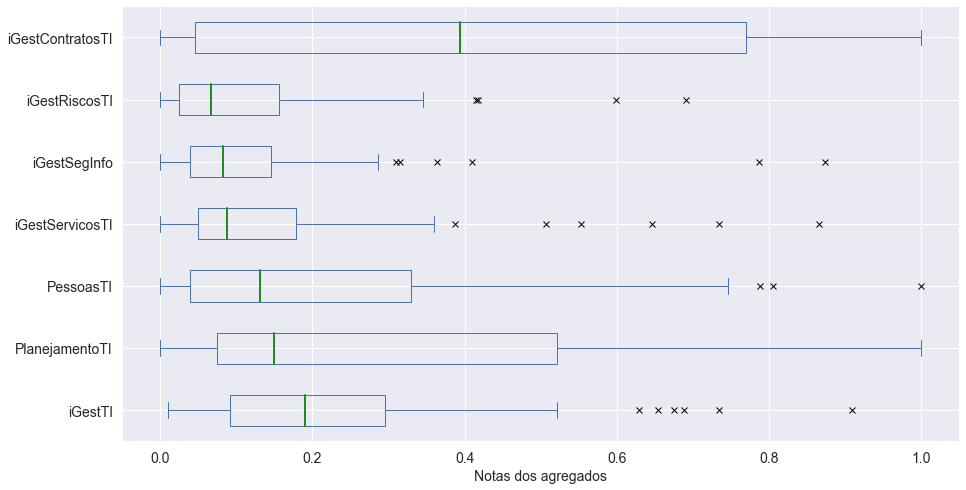

In [329]:
ax = df_resultado_igovti_ex_outliers.filter(regex='^([^0-9]*)$').sort_values(by='iGestTI', ascending=False)[
    ['iGestTI', 'PlanejamentoTI', 'PessoasTI', 'iGestServicosTI', 'iGestSegInfo', 'iGestRiscosTI', 'iGestContratosTI']
].plot.box(vert=False, figsize=(15, 8), fontsize=14, showmeans=False, medianprops = dict(color = "forestgreen", linewidth = 2), flierprops = dict(marker = "x"))

ax.set_xlabel('Notas dos agregados', fontsize=14)

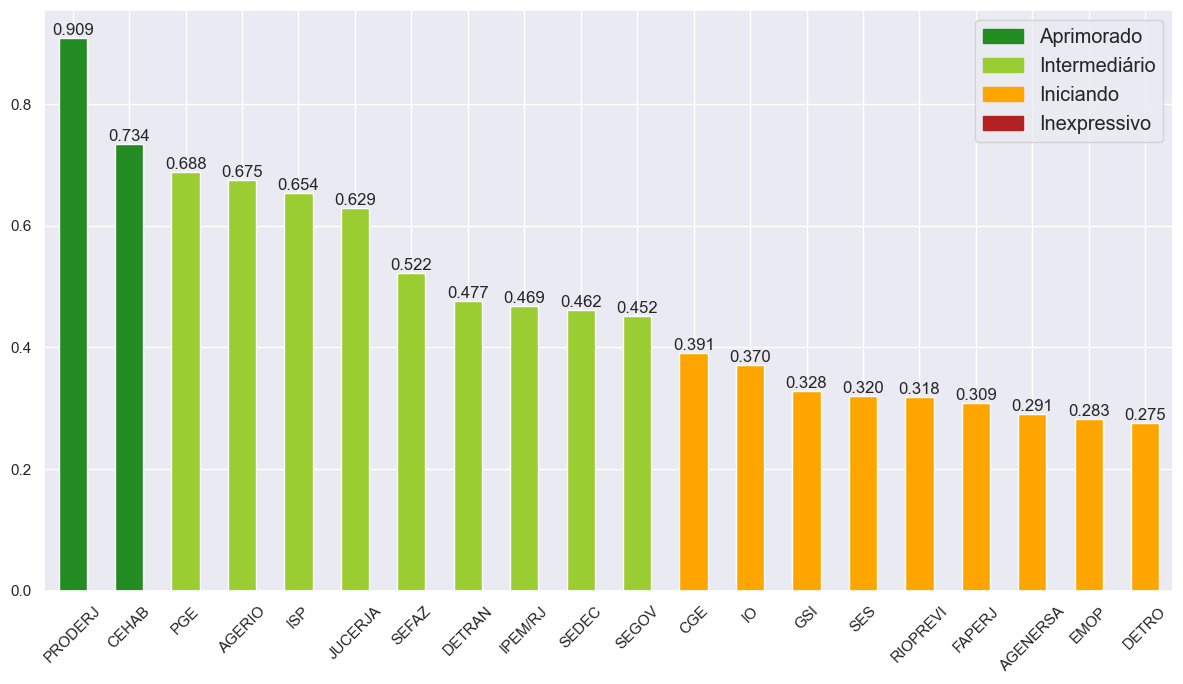

In [39]:
dados = df_resultado_igovti_ex_outliers.sort_values(by='iGestTI', ascending=False).head(20)

def get_color(d):
    if d < 0.15: return 'firebrick'
    elif d < 0.4: return 'orange'
    elif d < 0.7: return 'yellowgreen'
    else: return 'forestgreen'

cores = [ get_color(d) for d in dados['iGestTI']]

ax = dados['iGestTI']\
    .plot.bar(figsize=(12, 7), rot=45, color=cores)

ax.set_xlabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

legendas = [
    ('Aprimorado', 'forestgreen'),
    ('Intermediário', 'yellowgreen'),
    ('Iniciando', 'orange'),    
    ('Inexpressivo', 'firebrick')
]

m_legs = [ mpatches.Patch(color=l[1], label=l[0]) for l in legendas]
ax.legend(handles=m_legs,  fontsize='large')

plt.tight_layout()

## Componentes do iGestSegInfo

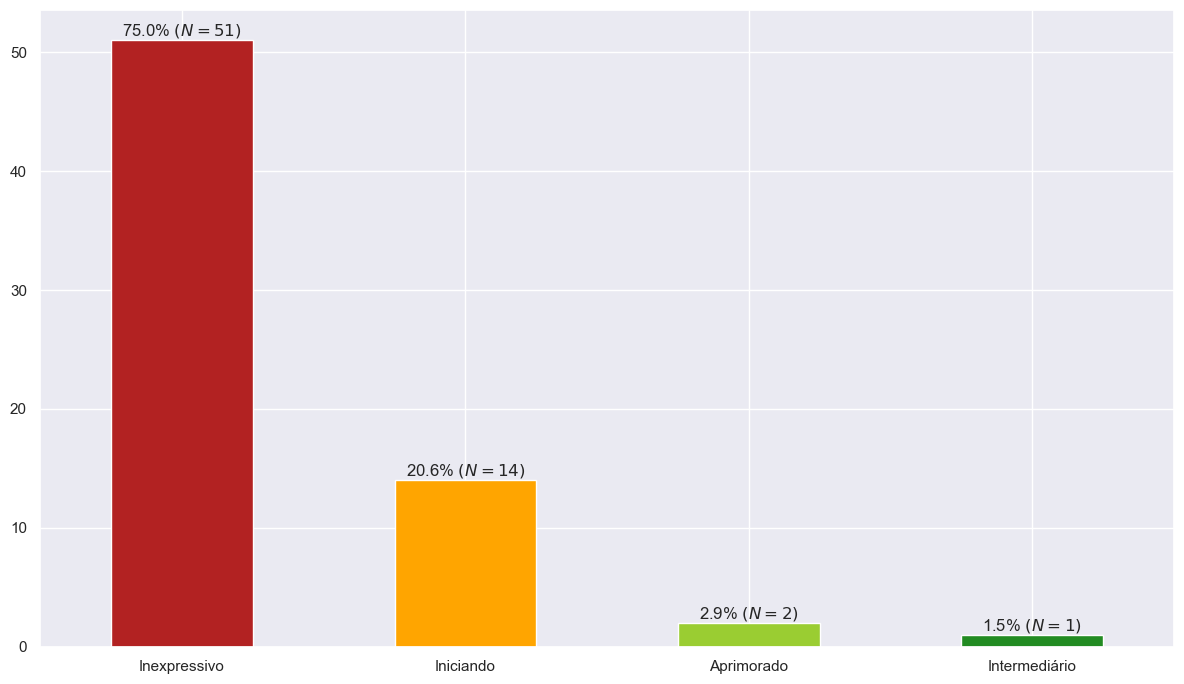

In [42]:
def get_nivel_capacidade(d):
    if d < 0.15: return 'Inexpressivo'
    elif d < 0.4: return 'Iniciando'
    elif d < 0.7: return 'Intermediário'
    else: return 'Aprimorado'

dados = df_resultado_igovti_ex_outliers.sort_values(by='iGestSegInfo', ascending=False)
dados['nivel_capacidade'] = dados['iGestSegInfo'].apply(get_nivel_capacidade)
dados = dados['nivel_capacidade'].value_counts()

ax = dados \
    .plot.bar(figsize=(12, 7), rot=0,
              color=['firebrick', 'orange', 'yellowgreen', 'forestgreen'])

labels = [f'{100*d/dados.sum():.1f}% $(N={d})$' for d in dados.values]

for container in ax.containers:
    ax.bar_label(container, labels)
    
plt.tight_layout()

In [44]:
df_medias.loc[['iGestSegInfo', 'EstruturaSegInfo', 'ProcessoSegInfo'][::-1], ['Média Ajustada (ex-outliers)', 'Administração Direta', 'Autarquia', 'Empresa Pública', 'Fundação', 'Sociedade de Economia Mista']].applymap('{:.4f}'.format)


,Média Ajustada (ex-outliers),Administração Direta,Autarquia,Empresa Pública,Fundação,Sociedade de Economia Mista
ProcessoSegInfo,0.1744,0.2188,0.2135,0.1749,0.0611,0.1952
EstruturaSegInfo,0.1295,0.0998,0.2146,0.1605,0.0639,0.1423
iGestSegInfo,0.1253,0.1232,0.1658,0.1257,0.0542,0.1864


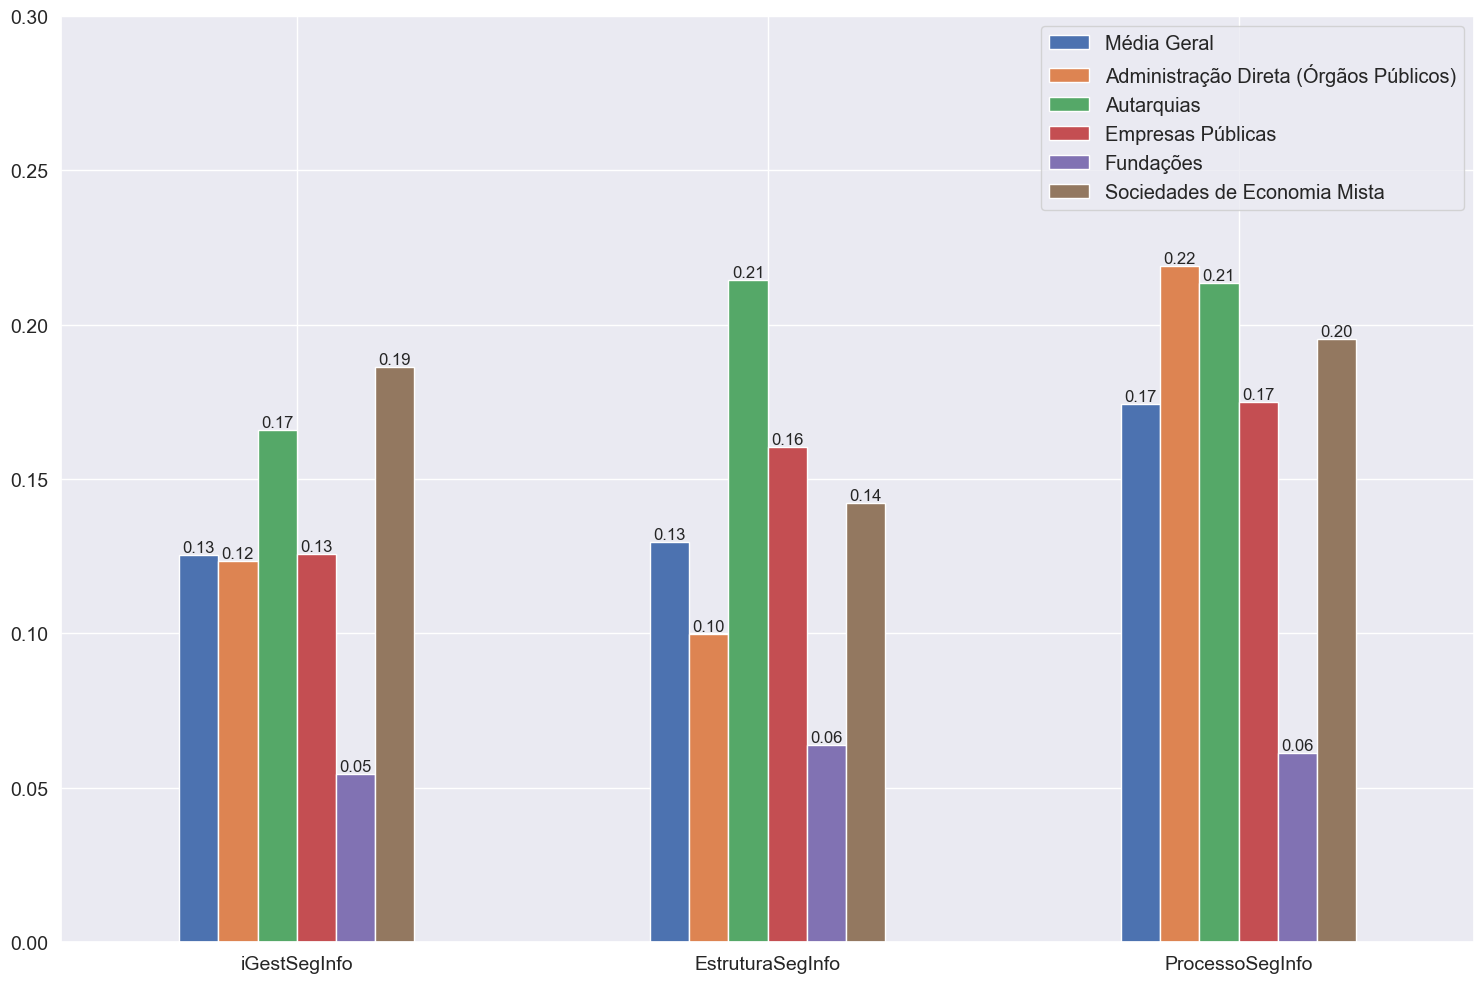

In [51]:
ax = df_medias.loc[['iGestSegInfo', 'EstruturaSegInfo', 'ProcessoSegInfo'], ['Média Ajustada (ex-outliers)', 'Administração Direta', 'Autarquia', 'Empresa Pública', 'Fundação', 'Sociedade de Economia Mista']]\
    .plot.bar(figsize=(15, 10), rot=0, fontsize=14)

ax.legend([
    'Média Geral', 'Administração Direta (Órgãos Públicos)', 'Autarquias', 'Empresas Públicas', 'Fundações', 'Sociedades de Economia Mista'
], fontsize='large')

ax.set_ylim([0, 0.3])
#ax.set_xlabel(fontsize=14)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.tight_layout()

In [55]:
df_resultado_igovti_ex_outliers[
    ['iGestSegInfo', 'EstruturaSegInfo', 'ProcessoSegInfo']
].describe()

df_resultado_igovti_ex_outliers.filter(regex='^([^0-9]*)$').describe()

,ResultadoTI,ModeloTI,MonitorAvaliaTI,PessoasTI,PlanejamentoTI,iGestServicosTI,iGestNiveisServicoTI,iGestRiscosTI,EstruturaSegInfo,ProcessoSegInfo,ProcessoSoftware,iGestProjetosTI,iGestContratosTI,GovernancaTI,iGestSegInfo,ProcessosTI,iGestTI,iGovTI,ProcessosContratacao
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,67.000000
mean,0.194283,0.171650,0.079021,0.222243,0.314461,0.153182,0.088123,0.119631,0.129510,0.174381,0.204718,0.164706,0.460088,0.146845,0.125262,0.175649,0.235497,0.191171,0.447558
std,0.146215,0.222314,0.188270,0.234771,0.313399,0.173036,0.160764,0.143115,0.211746,0.169401,0.296499,0.258904,0.338264,0.153491,0.156678,0.155952,0.194457,0.160069,0.314600
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001921,0.010437,0.005218,0.000000
25%,0.095596,0.050000,0.000000,0.038457,0.075000,0.050000,0.000000,0.024809,0.000000,0.056371,0.000000,0.000000,0.046303,0.053227,0.039044,0.079961,0.092200,0.094545,0.150586
50%,0.154956,0.150000,0.035993,0.131205,0.150000,0.087592,0.008674,0.066285,0.050584,0.125665,0.100000,0.100000,0.394401,0.110741,0.081917,0.130012,0.190632,0.150106,0.381556
75%,0.269058,0.150000,0.056989,0.329878,0.521875,0.178686,0.150000,0.156236,0.116721,0.189337,0.167708,0.150000,0.770139,0.162755,0.145137,0.209170,0.295533,0.219208,0.715002
max,0.541832,1.000000,1.000000,1.000000,1.000000,0.865673,0.858333,0.691540,1.000000,0.747989,1.000000,1.000000,1.000000,0.758782,0.873995,0.764160,0.909023,0.718105,1.000000


Text(0.5, 0, 'Notas dos agregados')

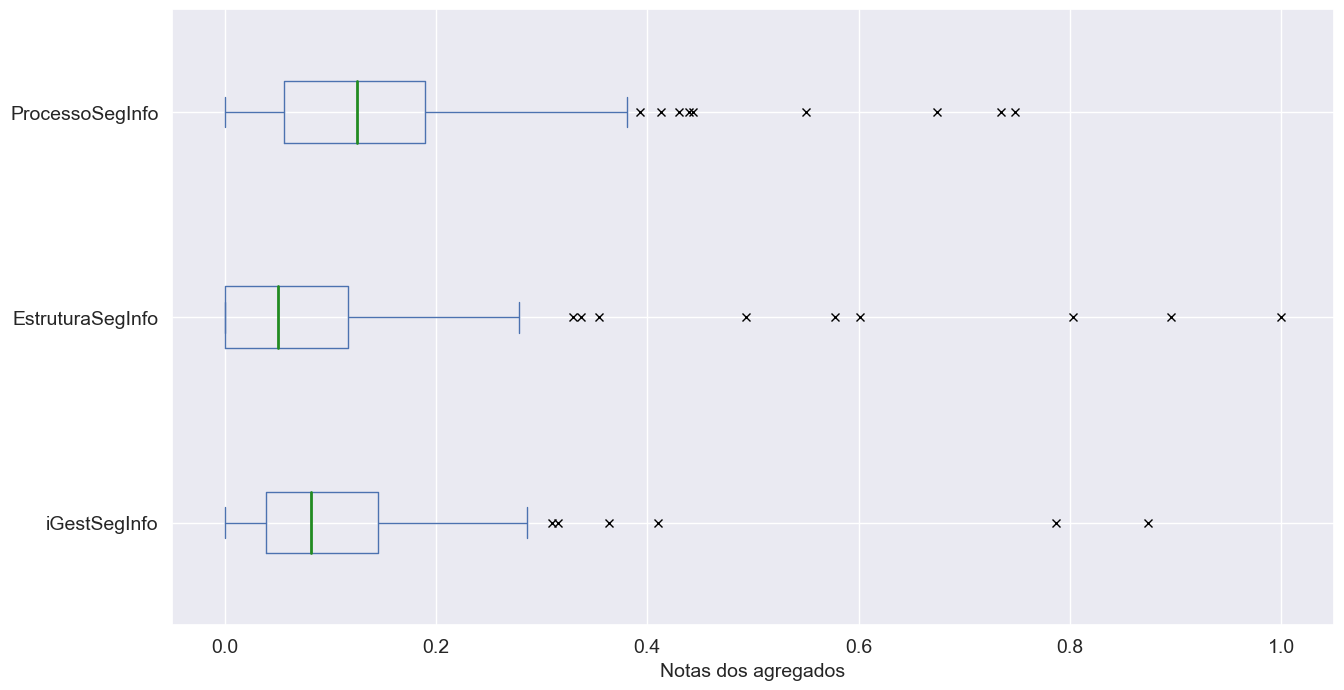

In [52]:
ax = df_resultado_igovti_ex_outliers.filter(regex='^([^0-9]*)$').sort_values(by='iGestTI', ascending=False)[
   ['iGestSegInfo', 'EstruturaSegInfo', 'ProcessoSegInfo']
].plot.box(vert=False, figsize=(15, 8), fontsize=14, showmeans=False, medianprops = dict(color = "forestgreen", linewidth = 2), flierprops = dict(marker = "x"))

ax.set_xlabel('Notas dos agregados', fontsize=14)

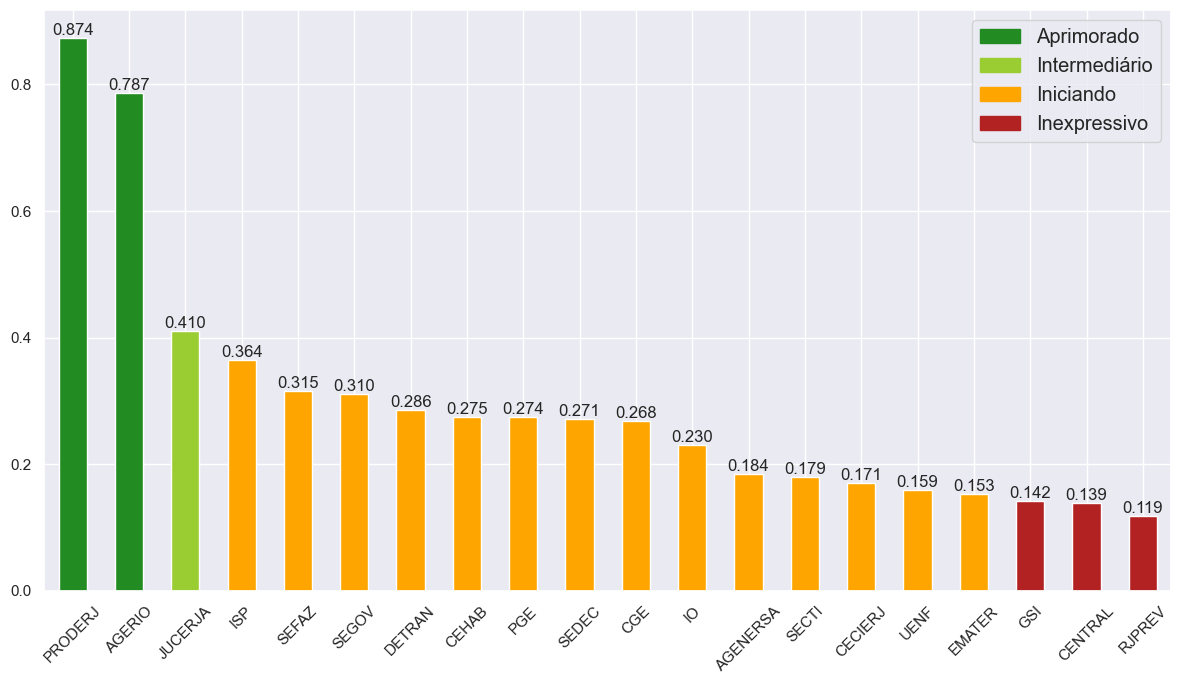

In [53]:
dados = df_resultado_igovti_ex_outliers.sort_values(by='iGestSegInfo', ascending=False).head(20)

def get_color(d):
    if d < 0.15: return 'firebrick'
    elif d < 0.4: return 'orange'
    elif d < 0.7: return 'yellowgreen'
    else: return 'forestgreen'

cores = [ get_color(d) for d in dados['iGestSegInfo']]

ax = dados['iGestSegInfo']\
    .plot.bar(figsize=(12, 7), rot=45, color=cores)

ax.set_xlabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

legendas = [
    ('Aprimorado', 'forestgreen'),
    ('Intermediário', 'yellowgreen'),
    ('Iniciando', 'orange'),    
    ('Inexpressivo', 'firebrick')
]

m_legs = [ mpatches.Patch(color=l[1], label=l[0]) for l in legendas]
ax.legend(handles=m_legs,  fontsize='large')

plt.tight_layout()